In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy, math

In [2]:
housing_data = pd.read_csv("./data/housing.csv")

In [5]:
housing_data.drop(columns=["Unnamed: 0", "zip_code"], inplace=True)

In [8]:
arr_data = np.array(housing_data)

In [30]:
housing_data

,beds,baths,size,price
0,3,2.5,2590.0,795000.0
1,4,2.0,2240.0,915000.0
2,4,3.0,2040.0,950000.0
3,4,3.0,3800.0,1950000.0
4,2,2.0,1042.0,950000.0
...,...,...,...,...
2011,3,2.0,1370.0,910000.0
2012,1,1.0,889.0,550000.0
2013,4,2.0,2140.0,1150000.0
2014,2,2.0,795.0,590000.0


In [14]:
x_train = arr_data[:,[0,1,2]]
y_train = arr_data[:,3]

In [15]:
y_train

array([ 795000.,  915000.,  950000., ..., 1150000.,  590000.,  659000.],
      shape=(2016,))

In [29]:
y_train.shape

(2016,)

In [44]:
def cost_function(x, y, w, b):
    m = x.shape[0]
    cost = 0

    for i in range(m):
        err = np.dot(w,x[i]) + b
        cost += (err - y[i])**2
    cost = cost/ (2*m)
    return cost

In [41]:
def compute_gradient(x, y, w, b):
    m,n = x.shape
    dj_dw = np.zeros(n)
    dj_db = 0

    for i in range(m):
        err = (np.dot(w,x[i]) + b) - y[i]
        for j in range (n):
            dj_dw[j] = dj_dw[j] + err * x[i,j]
        dj_db = dj_db + err

    dj_dw = dj_dw/m
    dj_db = dj_db/m

    return dj_dw, dj_db

In [42]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, 53.36032453])
tmp_dj_dw,tmp_dj_db = compute_gradient(x_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: -870178.7372879463
dj_dw at initial w,b: 
 [-2.78671749e+06 -2.14675192e+06 -1.85086802e+09]


In [59]:
def gradient_descent(x, y, w_in, b_in, cost_function, compute_gradient, alpha, epochs):

    w = copy.deepcopy(w_in)
    b = b_in
    j_history = []

    for i in range(epochs):
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i<10000:
            j_history.append(cost_function(x,y,w,b))

        if i%math.ceil(epochs/10) == 0:
            print(f"Iteration{i:4d}: Cost{j_history[-1]:8.2f}")
    return w, b, j_history
    

In [60]:
initial_w = np.zeros_like(w_init)
initial_b = 0.
iterations = 1000
alpha = 5.0e-7 
w_final, b_final, J_hist = gradient_descent(x_train, y_train, initial_w, initial_b,
                                                    cost_function, compute_gradient, 
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = x_train.shape
for i in range(m):
    print(f"prediction: {np.dot(x_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration   0: Cost835076272240.86
Iteration 100: Cost360837510852.91
Iteration 200: Cost360837063859.62
Iteration 300: Cost360836829428.95
Iteration 400: Cost360836595010.55
Iteration 500: Cost360836360604.33
Iteration 600: Cost360836126210.29
Iteration 700: Cost360835891828.43
Iteration 800: Cost360835657458.74
Iteration 900: Cost360835423101.24
b,w found by gradient descent: 19.17,[ -8.9080852   27.42450971 533.33050932] 
prediction: 1381387.02, target value: 795000.0
prediction: 1194698.72, target value: 915000.0
prediction: 1088060.05, target value: 950000.0
prediction: 2026721.74, target value: 1950000.0
prediction: 555786.59, target value: 950000.0
prediction: 634719.51, target value: 740000.0
prediction: 357369.12, target value: 460000.0
prediction: 2405391.21, target value: 3150000.0
prediction: 810723.38, target value: 565000.0
prediction: 1248031.77, target value: 699000.0
prediction: 704043.56, target value: 899000.0
prediction: 960042.21, target value: 1050000.0
prediction

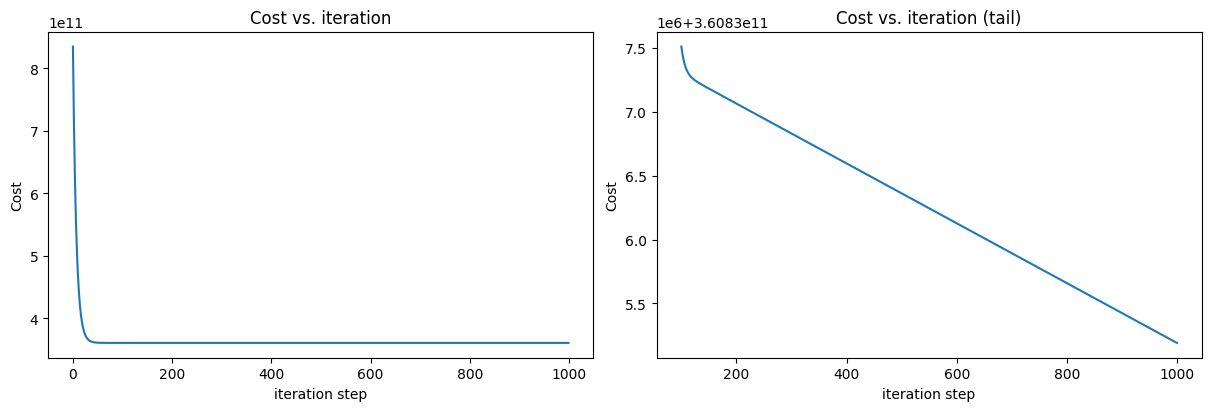

In [61]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()